<b>PRCP-1016 Heart Disease Prediction Project</b></br>
<b>Objective</b></br>
<ul><li>Perform Exploratory Data Analysis (EDA).</li>
<li>Build multiple Machine Learning models.</li>
<li>Compare model performance.</li>
<li>Select the best model.</li>
<li>Provide recommendations to hospitals.</li></ul>

Notebook Structure
1. Import Libraries

In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

2. Load Dataset

In [20]:
df = pd.read_csv("labels.csv")

In [21]:
df = pd.read_csv("values.csv")

3. Basic Exploration

Perform:

<ul><li>Shape</li>
<li>Columns</li>
<li>Data Types</li>
<li>Head</li>
<li>Tail</li>
<li>Info</li>
<li>Statistical Summary</li></ul>

In [22]:
df.shape



(180, 14)

In [23]:
df.head()



,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [24]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [25]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000


4. Check Missing Values

In [26]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
dtype: int64

5. Check Duplicate Values

In [27]:
df.duplicated().sum()



np.int64(0)

6. Remove Unnecessary Column

In [28]:
df.drop("patient_id", axis=1, inplace=True)

7. Exploratory Data Analysis (EDA)

Include:

Target Variable Distribution

<Axes: xlabel='sex', ylabel='count'>

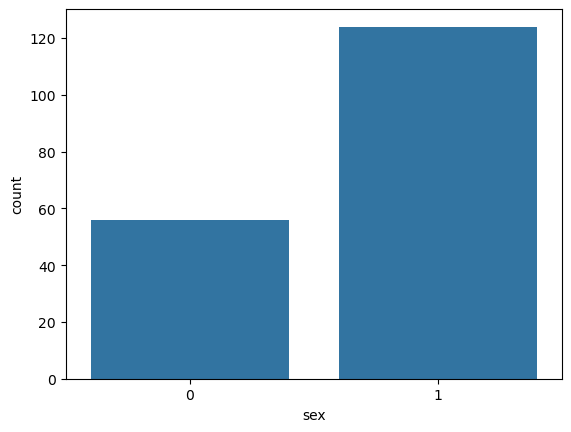

In [29]:
sns.countplot(x='sex',data=df)

Age Distribution

<Axes: xlabel='age', ylabel='Count'>

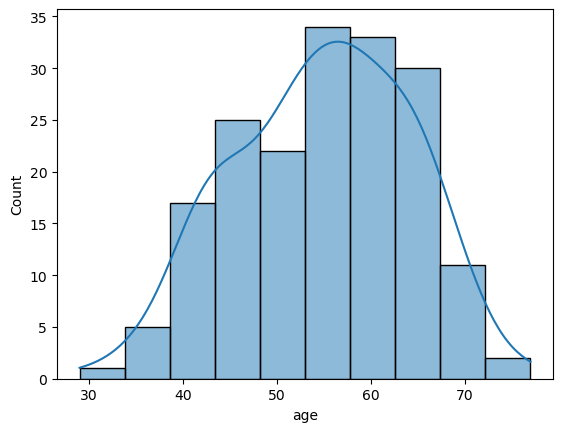

In [30]:
sns.histplot(df['age'], kde=True)

Correlation Heatmap

In [31]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True)

ValueError: could not convert string to float: 'normal'

<Figure size 1200x1000 with 0 Axes>

Boxplots

In [ ]:
sns.boxplot(df['serum_cholesterol_mg_per_dl'])

In [ ]:
sns.boxplot(df['fasting_blood_sugar_gt_120_mg_per_dl'])

Pairplot

In [ ]:
sns.pairplot(df)

8. Outlier Detection

Use Boxplots

OR

IQR Method

In [ ]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1

df=df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]

9. Encoding

Encode

In [ ]:
thal

In [ ]:
le=LabelEncoder()

df['thal']=le.fit_transform(df['thal'])

10. Feature & Target Separation

In [ ]:
X=df.drop("age",axis=1)

y=df["age"]

11. Train Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42)

12. Feature Scaling

In [ ]:
sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

13. Model Building</br>
Train:</br>

Logistic Regression</br>
Decision Tree</br>
Random Forest</br>
KNN</br>
SVM</br>
Naive Bayes</br>
Extra Trees

In [ ]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

pred=lr.predict(x_test)

In [ ]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred=dt.predict(x_test)

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [ ]:
# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [ ]:
# SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

In [ ]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)


In [ ]:
# Extra Trees
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train, y_train)
pred_et = et.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("KNN:", accuracy_score(y_test, pred_knn))
print("SVM:", accuracy_score(y_test, pred_svm))
print("Naive Bayes:", accuracy_score(y_test, pred_nb))
print("Extra Trees:", accuracy_score(y_test, pred_et))

14. Model Evaluation</br>

Evaluate each model using</br>

Accuracy</br>
Precision</br>
Recall</br>
F1 Score</br>
ROC-AUC</br>
Cross Validation</br>

In [ ]:
accuracy_score(y_test,pred)

precision_score(y_test,pred)

recall_score(y_test,pred)

f1_score(y_test,pred)

roc_auc_score(y_test,pred)

Cross Validation

In [ ]:
cross_val_score(lr,X,y,cv=10).mean()

15. Confusion Matrix

In [ ]:
cm=confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')

16. Classification Report

In [ ]:
print(classification_report(y_test,pred))

17. ROC Curve

In [ ]:
prob=lr.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],'--')

18. Feature Importance

In [ ]:
model=ExtraTreesClassifier()

model.fit(X,y)

feat_importances=pd.Series(
model.feature_importances_,
index=X.columns)

feat_importances.nlargest(10).plot(kind='barh')

19. Hyperparameter Tuning

In [ ]:
param_grid={
'n_estimators':[100,200],
'max_depth':[5,10,15],
'min_samples_split':[2,5]
}

grid=GridSearchCV(
RandomForestClassifier(),
param_grid,
cv=5)

grid.fit(X_train,y_train)

grid.best_params_

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN',
        'SVM',
        'Naive Bayes',
        'Extra Trees'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_et)
    ],
    
    'Precision': [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_svm),
        precision_score(y_test, pred_nb),
        precision_score(y_test, pred_et)
    ],
    
    'Recall': [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_svm),
        recall_score(y_test, pred_nb),
        recall_score(y_test, pred_et)
    ],
    
    'F1 Score': [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_svm),
        f1_score(y_test, pred_nb),
        f1_score(y_test, pred_et)
    ]
})

comparison

In [ ]:
comparison.sort_values(by='Accuracy', ascending=False)

In [ ]:
comparison.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}'
})

<b>Task 1: Data Analysis Report</br></b>

Include:</br>

<ul><li>Dataset contains patient medical records used for predicting heart disease.</br></li>
<li>Removed patient_id because it does not contribute to prediction.</br></li>
<li>Checked missing values and duplicates.</br></li>
<li>Encoded categorical variables.</br></li>
<li>Performed EDA using histograms, countplots, heatmaps, and boxplots.</br></li>
<li>Detected and handled outliers.</br></li>
<li>Standardized numerical features.</br></li>
<li>Identified important features influencing heart disease.</br></li>
<li>Split data into training and testing sets.</br></li></ul>

<b>Task 2: Machine Learning Report</b>

Build and compare:

<ul><li>Logistic Regression</li>
<li>Decision Tree</li>
<li>Random Forest</li>
<li>KNN</li>
<li>SVM</li>
<li>Naive Bayes</li>
<li>Extra Trees</li></ul>

Evaluation Metrics:

<ul><li>Accuracy</li>
<li>Precision</li>
<li>Recall</li>
<li>F1 Score</li>
<li>ROC-AUC</li>
<li>Confusion Matrix</li>
<li>Classification Report</li>
<li>Cross Validation</li>
</li></ul>
Recommended Production Model:

Random Forest or Extra Trees for this dataset both are best model 

<b>Task 3: Suggestions to the Hospital</b>
<ol><li>Implement routine heart disease screening for individuals above 40 years of age.</li>
<li>Monitor patients with high blood pressure and elevated cholesterol regularly.</li>
<li>Encourage healthy lifestyles through diet, exercise, and smoking cessation programs.</li>
<li>Use the predictive model to identify high-risk patients early and prioritize preventive care.</li>
<li>Schedule regular follow-up appointments for patients with multiple cardiovascular risk factors.</li>
<li>Integrate the prediction model into the hospital information system for real-time risk assessment.</li>
<li>Promote awareness campaigns about heart disease symptoms and prevention.</li>
<li>Recommend regular ECG and stress tests for high-risk individuals.</li>
<li>Use model predictions to optimize healthcare resources and reduce emergency admissions.</li>
<li>Continuously retrain the model with new patient data to improve prediction accuracy.</li></ol>